# Setting up

In [ ]:
# ============================================
# CELL 1: Setup and Authentication
# ============================================

from google.colab import auth
auth.authenticate_user()

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Set nice plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

PROJECT_ID = 'project-9088eb2a-a4cc-4580-8e6'

print("Setup complete!")

Setup complete!


In [ ]:
# ============================================
# CELL 2: Helper function to query BigQuery
# This saves you from repeating code
# ============================================

from google.cloud import bigquery

client = bigquery.Client(project=PROJECT_ID)

def run_query(sql):
    """Run a BigQuery SQL query and return a Pandas DataFrame"""
    return client.query(sql).to_dataframe()

# Test it
test = run_query("SELECT 'Connected!' as status")
print(test)

       status
0  Connected!


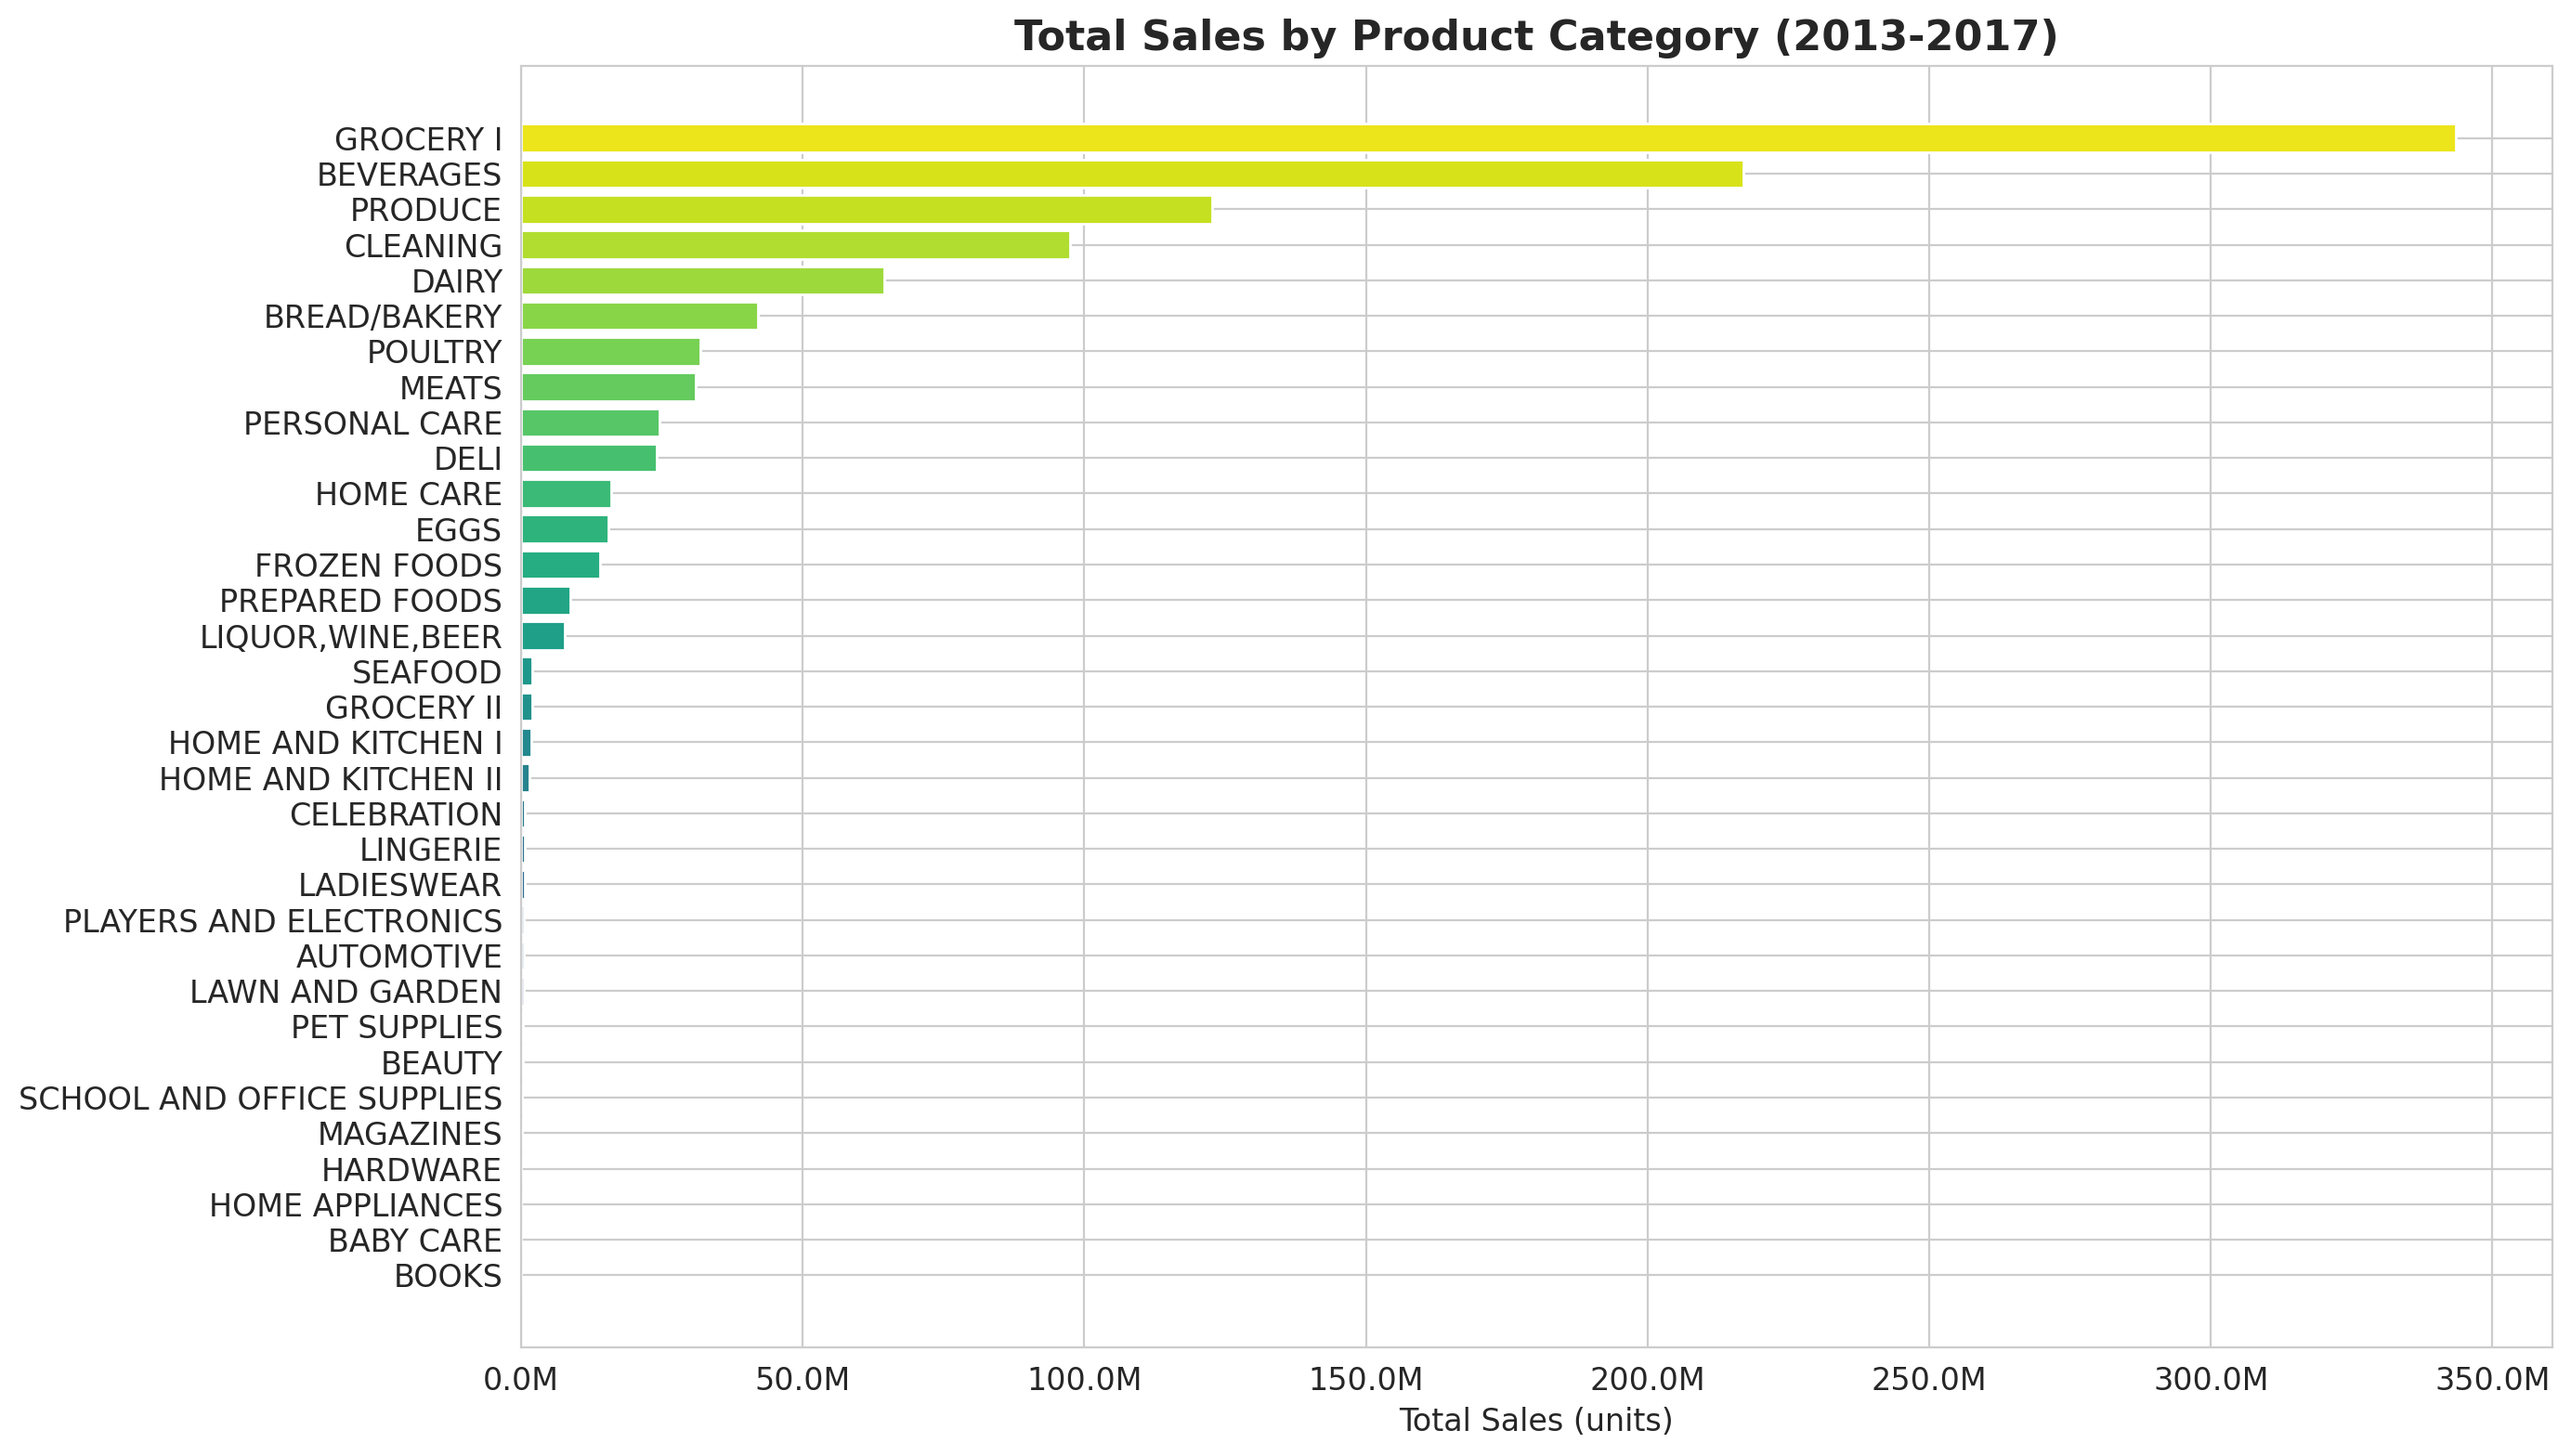

In [ ]:
# ============================================
# CELL 3: CHART 1 — Sales by Product Category (Bar Chart)
# ============================================

df_categories = run_query("""
    SELECT
        family as product_category,
        ROUND(SUM(sales), 0) as total_sales,
        ROUND(AVG(sales), 2) as avg_daily_sales
    FROM `demand_forecasting.sales`
    GROUP BY family
    ORDER BY total_sales DESC
""")

fig, ax = plt.subplots(figsize=(14, 8),dpi=200)
bars = ax.barh(
    df_categories['product_category'][::-1],
    df_categories['total_sales'][::-1],
    color=sns.color_palette("viridis", len(df_categories))
)
ax.set_xlabel('Total Sales (units)')
ax.set_title('Total Sales by Product Category (2013-2017)', fontsize=16, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig('category_sales.png', dpi=150, bbox_inches='tight')
plt.show()

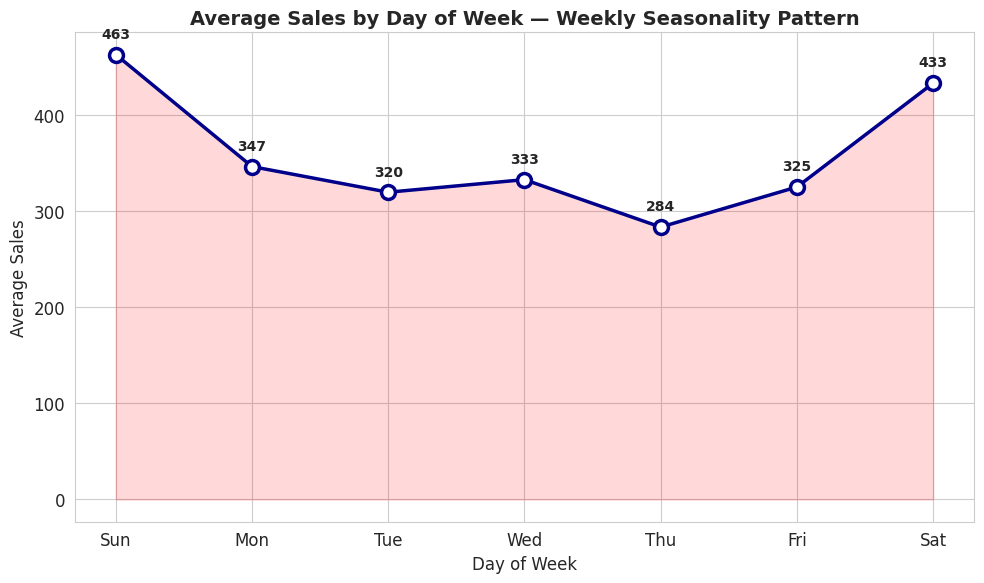

In [ ]:
# ============================================
# CELL 4: CHART 2 — Day of Week Pattern (Line Chart)
# ============================================

df_dow = run_query("""
    SELECT
        EXTRACT(DAYOFWEEK FROM PARSE_DATE('%Y-%m-%d', date)) as day_num,
        CASE EXTRACT(DAYOFWEEK FROM PARSE_DATE('%Y-%m-%d', date))
            WHEN 1 THEN 'Sun'
            WHEN 2 THEN 'Mon'
            WHEN 3 THEN 'Tue'
            WHEN 4 THEN 'Wed'
            WHEN 5 THEN 'Thu'
            WHEN 6 THEN 'Fri'
            WHEN 7 THEN 'Sat'
        END as day_name,
        ROUND(AVG(sales), 2) as avg_sales
    FROM `demand_forecasting.sales`
    GROUP BY day_num, day_name
    ORDER BY day_num
""")
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df_dow['day_name'], df_dow['avg_sales'],
        marker='o', linewidth=2.5, markersize=10,
        color='darkblue', markerfacecolor='white',
        markeredgewidth=2.5)

ax.fill_between(df_dow['day_name'], df_dow['avg_sales'],
                alpha=0.15, color='red')

ax.set_xlabel('Day of Week')
ax.set_ylabel('Average Sales')
ax.set_title('Average Sales by Day of Week — Weekly Seasonality Pattern',
             fontsize=14, fontweight='bold')

# Add value labels
for i, row in df_dow.iterrows():
    ax.annotate(f"{row['avg_sales']:.0f}",
                (row['day_name'], row['avg_sales']),
                textcoords="offset points", xytext=(0, 12),
                ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('weekly_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

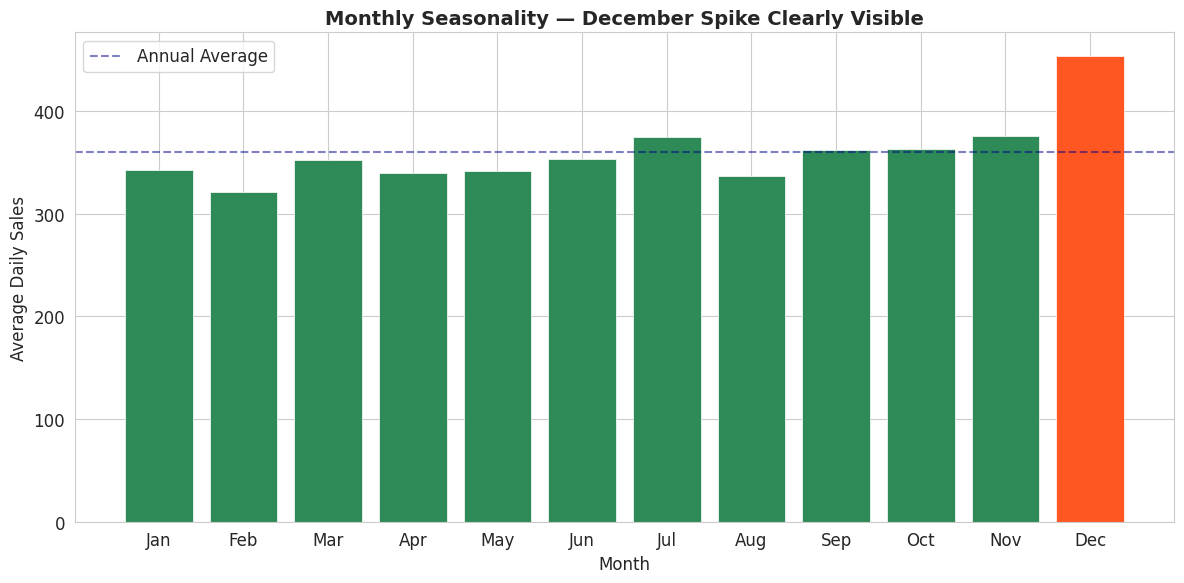

In [ ]:
# ============================================
# CELL 5: CHART 3 — Monthly Seasonality (Bar + Line)
# ============================================

df_monthly = run_query("""
    SELECT
        EXTRACT(MONTH FROM PARSE_DATE('%Y-%m-%d', date))as month_num,
        CASE EXTRACT(MONTH FROM PARSE_DATE('%Y-%m-%d', date))
            WHEN 1 THEN 'Jan' WHEN 2 THEN 'Feb'
            WHEN 3 THEN 'Mar' WHEN 4 THEN 'Apr'
            WHEN 5 THEN 'May' WHEN 6 THEN 'Jun'
            WHEN 7 THEN 'Jul' WHEN 8 THEN 'Aug'
            WHEN 9 THEN 'Sep' WHEN 10 THEN 'Oct'
            WHEN 11 THEN 'Nov' WHEN 12 THEN 'Dec'
        END as month_name,
        ROUND(AVG(sales), 2) as avg_sales,
        ROUND(SUM(sales), 0) as total_sales
    FROM `demand_forecasting.sales`
    GROUP BY month_num, month_name
    ORDER BY month_num
""")

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#FF5722' if m == 'Dec' else 'seagreen'
          for m in df_monthly['month_name']]

bars = ax.bar(df_monthly['month_name'], df_monthly['avg_sales'],
              color=colors, edgecolor='white', linewidth=0.5)

# Highlight December
ax.axhline(y=df_monthly['avg_sales'].mean(), color='darkblue',
           linestyle='--', alpha=0.5, label='Annual Average')

ax.set_xlabel('Month')
ax.set_ylabel('Average Daily Sales')
ax.set_title('Monthly Seasonality — December Spike Clearly Visible',
             fontsize=14, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('monthly_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_184/1405220476.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly_trend = df_yearly.set_index('date').resample('M').mean().reset_index()


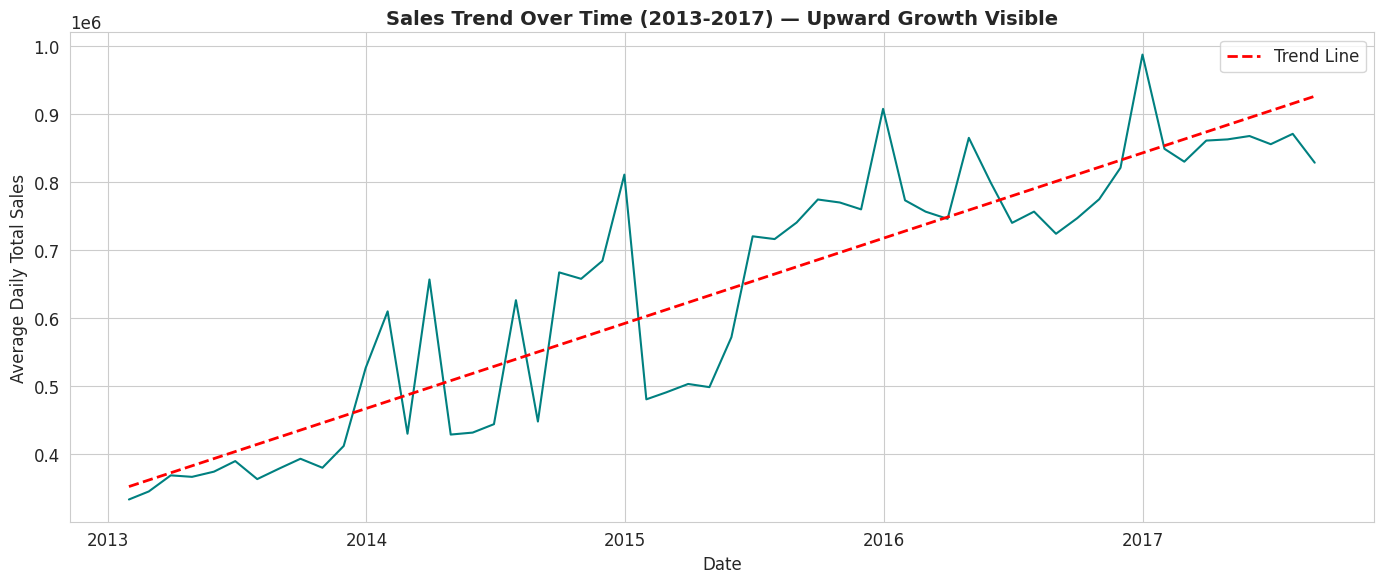

In [ ]:
# ============================================
# CELL 6: CHART 4 — Year over Year Trend
# ============================================

df_yearly = run_query("""
    SELECT
        date,
        SUM(sales) as daily_total_sales
    FROM `demand_forecasting.sales`
    GROUP BY date
    ORDER BY date
""")

df_yearly['date'] = pd.to_datetime(df_yearly['date'])

# Monthly aggregation for cleaner chart
df_monthly_trend = df_yearly.set_index('date').resample('M').mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_monthly_trend['date'],
        df_monthly_trend['daily_total_sales'],
        linewidth=1.5, color='teal')

# Add trend line
from numpy.polynomial import polynomial as P
x_numeric = (df_monthly_trend['date'] - df_monthly_trend['date'].min()).dt.days.values
coeffs = P.polyfit(x_numeric, df_monthly_trend['daily_total_sales'].values, 1)
trend = P.polyval(x_numeric, coeffs)
ax.plot(df_monthly_trend['date'], trend,
        '--', color='red', linewidth=2, label='Trend Line')

ax.set_xlabel('Date')
ax.set_ylabel('Average Daily Total Sales')
ax.set_title('Sales Trend Over Time (2013-2017) — Upward Growth Visible',
             fontsize=14, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()

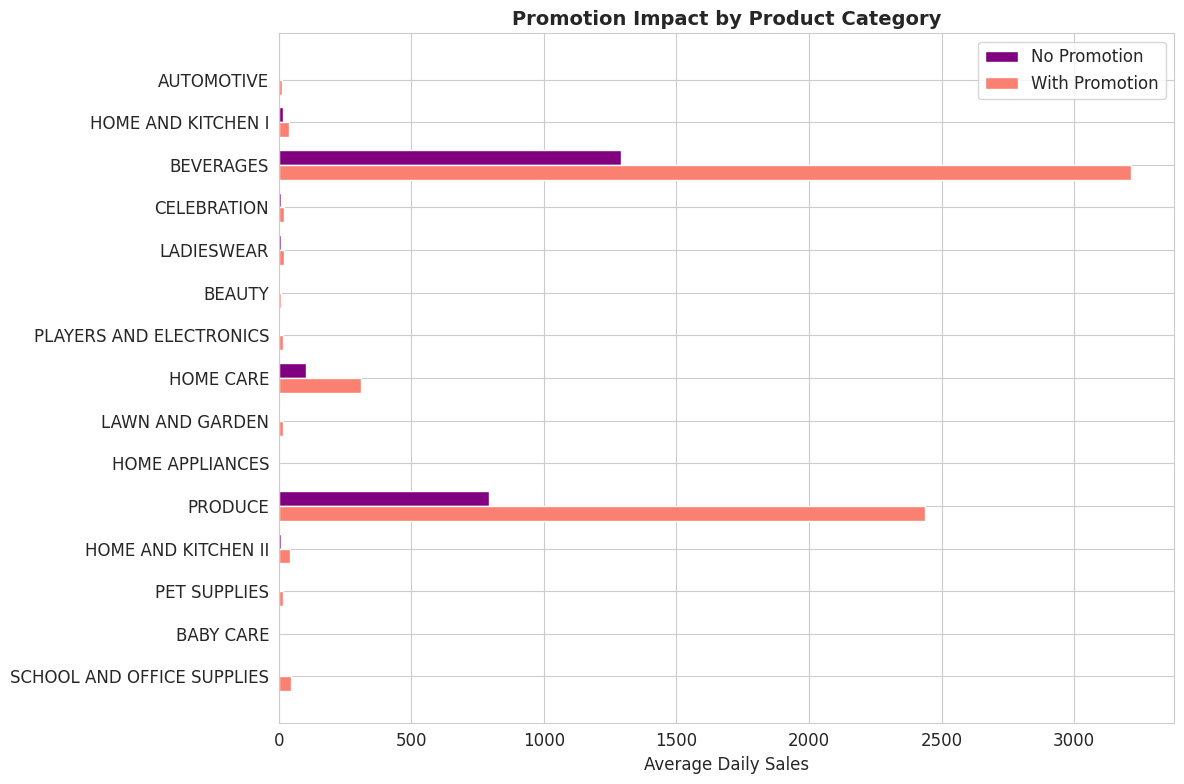

In [ ]:
# ============================================
# CELL 7: CHART 5 — Promotion Impact by Category
# ============================================

df_promo = run_query("""
    SELECT
        family as product_category,
        ROUND(AVG(CASE WHEN onpromotion > 0 THEN sales END), 2) as sales_with_promo,
        ROUND(AVG(CASE WHEN onpromotion = 0 THEN sales END), 2) as sales_no_promo,
        ROUND(
            (AVG(CASE WHEN onpromotion > 0 THEN sales END) -
             AVG(CASE WHEN onpromotion = 0 THEN sales END)) * 100.0 /
            NULLIF(AVG(CASE WHEN onpromotion = 0 THEN sales END), 0), 1
        ) as promo_lift_pct
    FROM `demand_forecasting.sales`
    GROUP BY family
    HAVING sales_with_promo IS NOT NULL AND sales_no_promo IS NOT NULL
    ORDER BY promo_lift_pct DESC
    LIMIT 15
""")

fig, ax = plt.subplots(figsize=(12, 8))

x = range(len(df_promo))
width = 0.35

bars1 = ax.barh([i + width/2 for i in x],
                df_promo['sales_no_promo'],
                width, label='No Promotion', color='purple')
bars2 = ax.barh([i - width/2 for i in x],
                df_promo['sales_with_promo'],
                width, label='With Promotion', color='salmon')

ax.set_yticks(x)
ax.set_yticklabels(df_promo['product_category'])
ax.set_xlabel('Average Daily Sales')
ax.set_title('Promotion Impact by Product Category',
             fontsize=14, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('promotion_impact.png', dpi=150, bbox_inches='tight')
plt.show()

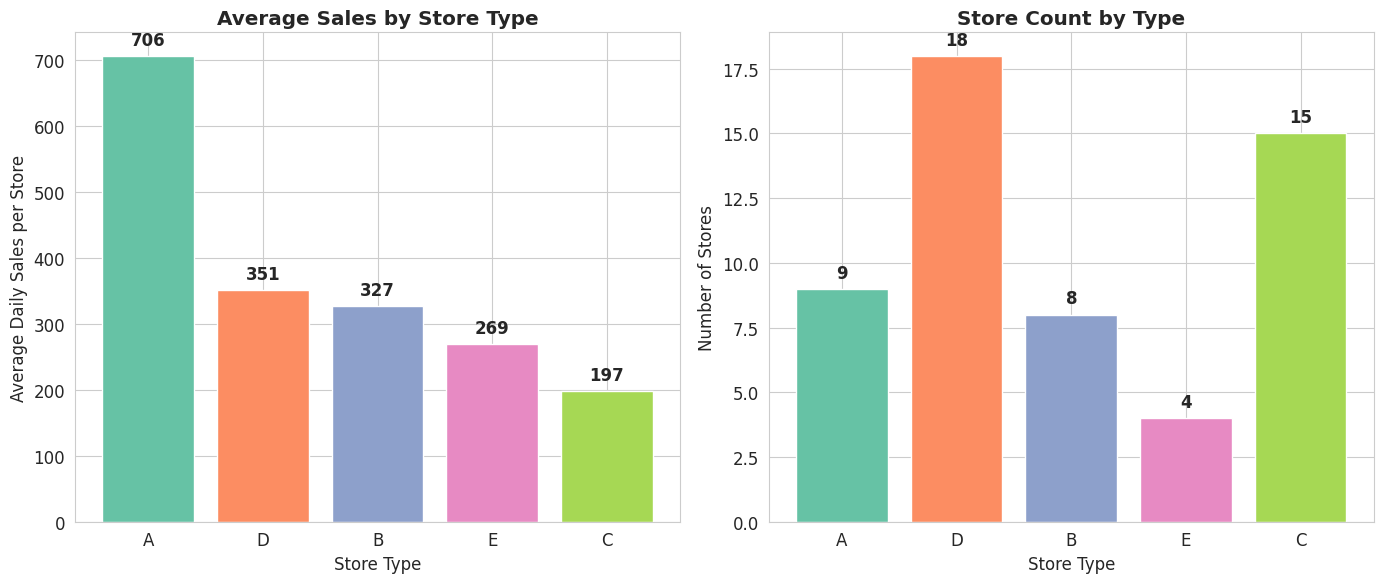

In [ ]:
# ============================================
# CELL 8: CHART 6 — Store Type Comparison
# ============================================

df_stores = run_query("""
    SELECT
        s.type as store_type,
        COUNT(DISTINCT s.store_nbr) as num_stores,
        ROUND(AVG(t.sales), 2) as avg_sales,
        ROUND(SUM(t.sales), 0) as total_sales
    FROM `demand_forecasting.sales` t
    JOIN `demand_forecasting.stores` s
        ON t.store_nbr = s.store_nbr
    GROUP BY s.type
    ORDER BY avg_sales DESC
""")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Avg sales by store type
ax1.bar(df_stores['store_type'], df_stores['avg_sales'],
        color=sns.color_palette("Set2", len(df_stores)))
ax1.set_xlabel('Store Type')
ax1.set_ylabel('Average Daily Sales per Store')
ax1.set_title('Average Sales by Store Type', fontweight='bold')

for i, row in df_stores.iterrows():
    ax1.annotate(f"{row['avg_sales']:.0f}",
                 (row['store_type'], row['avg_sales']),
                 textcoords="offset points", xytext=(0, 8),
                 ha='center', fontweight='bold')

# Chart 2: Number of stores per type
ax2.bar(df_stores['store_type'], df_stores['num_stores'],
        color=sns.color_palette("Set2", len(df_stores)))
ax2.set_xlabel('Store Type')
ax2.set_ylabel('Number of Stores')
ax2.set_title('Store Count by Type', fontweight='bold')

for i, row in df_stores.iterrows():
    ax2.annotate(f"{int(row['num_stores'])}",
                 (row['store_type'], row['num_stores']),
                 textcoords="offset points", xytext=(0, 8),
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('store_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

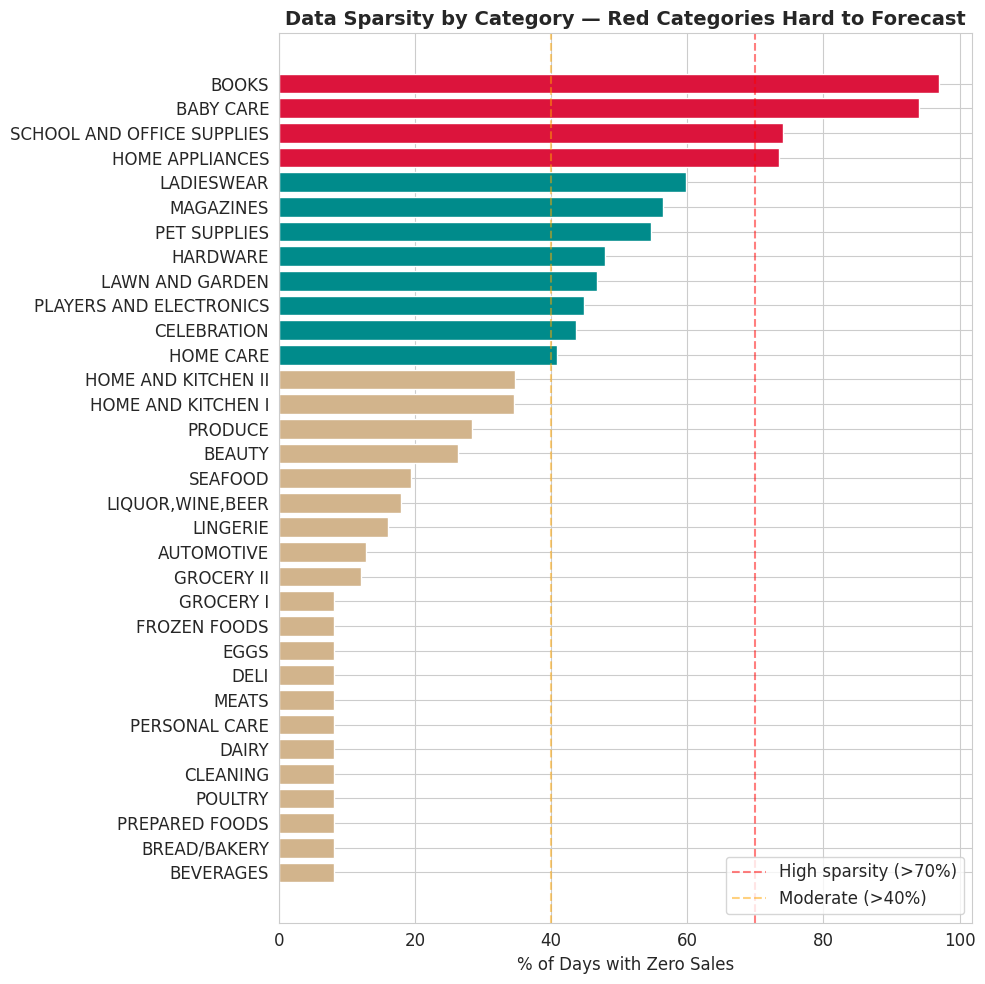

In [ ]:
# ============================================
# CELL 9: CHART 7 — Zero Sales Heatmap
# ============================================

df_zeros = run_query("""
    SELECT
        family as category,
        ROUND(COUNTIF(sales = 0) * 100.0 / COUNT(*), 1) as zero_pct
    FROM `demand_forecasting.sales`
    GROUP BY family
    ORDER BY zero_pct DESC
""")

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['crimson' if z > 70 else 'darkcyan' if z > 40 else 'tan'
          for z in df_zeros['zero_pct']]

ax.barh(df_zeros['category'][::-1],
        df_zeros['zero_pct'][::-1],
        color=colors[::-1], edgecolor='white')

ax.axvline(x=70, color='red', linestyle='--', alpha=0.5, label='High sparsity (>70%)')
ax.axvline(x=40, color='orange', linestyle='--', alpha=0.5, label='Moderate (>40%)')

ax.set_xlabel('% of Days with Zero Sales')
ax.set_title('Data Sparsity by Category — Red Categories Hard to Forecast',
             fontsize=14, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('zero_sales_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================
# CELL 22: Download all files
# ============================================

from google.colab import files

for filename in ['category_sales.png', 'monthly_seasonality.png',
                 'promotion_impact.png','sales_trend.png', 'store_analysis.png',
                 'weekly_seasonality.png','zero_sales_analysis.png']:
    try:
        files.download(filename)
        print(f"  ✅ {filename}")
    except:
        print(f"  ⚠️ {filename} not found")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ category_sales.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ✅ weekly_seasonality.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ zero_sales_analysis.png
